**Abstract**




Lo scopo del progetto è realizzare un modello di anomaly detection per  distinguere fra getti normali ed anomali fra i  rilevamenti di un esperimento di fisica delle particelle. E' stata effetuata preliminarmente una riduzione dimensionale con PCA che evidenzia la presenza di clusters distinti. Dunque è stato addestrato un autoencoder su un dataset di 12000 jet normali, rappresentati come immagini 2D 100x100.Il modello è stato testato su due dataset separati di 3000 esempi con un tasso di anomalie rispettivamente  del <45% (low) e >55% (high) e 3000 degli eventi normali. L'errore di ricostruzione dell' AE viene usato come metrica di rilevazione delle anomalie con una soglia di FPR del 10% sui normali.
\
Si è ottenuto:

1.  %anomaly in low $= (32.3 \pm 0.5 )\%$
2.   %anomaly in high $= (90\pm  1) \%$

A partire dallo spazio latente generato da tale AE si è realizzato un clustering. Le label di tale procedura sono state raccordata alle label ottenute con l'autoencoder in modo da massimizzare la purezza.
La purezza ottenuta è

1.   dataset high: $= (67 \pm 4)  \%$
2.   dataset low: $= (83 \pm 5) \%$




L'incertezza sui risultati ottenuti è stata calcolata in modo statistico valutando media e deviazione standard sui risultati ottenuti da diverse realizzazioni del modello

#Dataset

In [ ]:
# import delle librerie
import numpy as np
import matplotlib.pyplot as plt

# pytorch
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

from torch import nn
import torch.nn.functional as F

2.6.0+cu124
0.21.0+cu124


In [ ]:
#Importo i dati
!wget http://giagu.web.cern.ch/giagu/CERN/P2025/Normal_data.npz
!wget http://giagu.web.cern.ch/giagu/CERN/P2025/G23/Test_data_low.npz
!wget http://giagu.web.cern.ch/giagu/CERN/P2025/G23/Test_data_high.npz

--2025-06-29 18:21:14--  http://giagu.web.cern.ch/giagu/CERN/P2025/Normal_data.npz
Resolving giagu.web.cern.ch (giagu.web.cern.ch)... 137.138.55.232, 188.185.50.104, 188.185.5.88, ...
Connecting to giagu.web.cern.ch (giagu.web.cern.ch)|137.138.55.232|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://giagu.web.cern.ch/giagu/CERN/P2025/Normal_data.npz [following]
--2025-06-29 18:21:15--  https://giagu.web.cern.ch/giagu/CERN/P2025/Normal_data.npz
Connecting to giagu.web.cern.ch (giagu.web.cern.ch)|137.138.55.232|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6874623 (6.6M)
Saving to: ‘Normal_data.npz.4’

Normal_data.npz.4   100%[===================>]   6.56M  4.66MB/s    in 1.4s    

2025-06-29 18:21:17 (4.66 MB/s) - ‘Normal_data.npz.4’ saved [6874623/6874623]

--2025-06-29 18:21:17--  http://giagu.web.cern.ch/giagu/CERN/P2025/G23/Test_data_low.npz
Resolving giagu.web.cern.ch (giagu.web.cern.ch)... 188.185.5.88, 188.185.50.104

In [ ]:
f_train = np.load('Normal_data.npz')
f_test_l = np.load('Test_data_low.npz')
f_test_h = np.load('Test_data_high.npz')

normal_data = f_train['normal_data']
test_data_l = f_test_l['test_data']
test_data_h = f_test_h['test_data']

Di seguito immagini relative al dataset normale. Nelle parti successive si confronteranno tali immagini con quelle ritenute anomale.

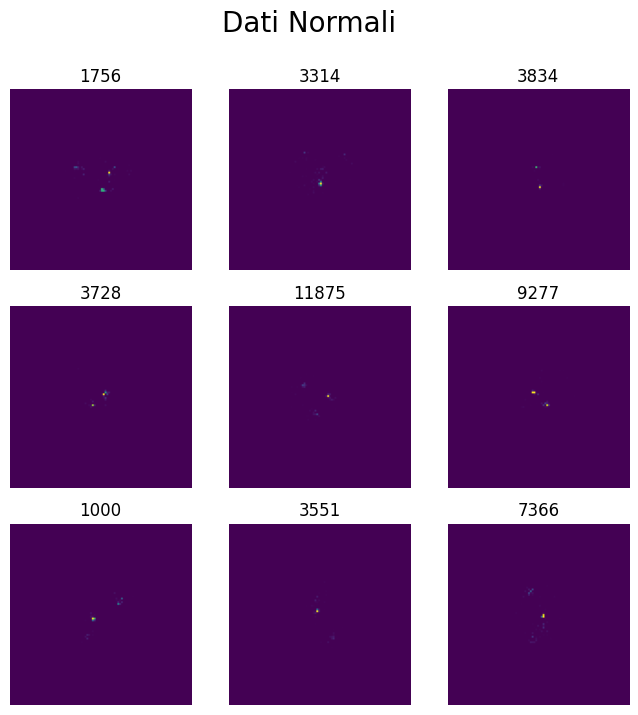

<Figure size 640x480 with 0 Axes>

In [ ]:
##plot dei dati normali

figure = plt.figure(figsize=(8, 8))
cols, rows = 3,3
images = normal_data
plt.suptitle("Dati Normali", fontsize=20)  # Titolo principale ben visibile
for i in range(1, cols * rows + 1):
    sample_idx = np.random.randint(len(images))
    img = images[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(sample_idx)
    plt.axis("off")
    plt.imshow(img.reshape((100,100)))
plt.show()
plt.tight_layout()





In [ ]:
#Verifico la shape attesa dei datasets
print(normal_data.shape)
print(test_data_l.shape)
print(test_data_h.shape)

(12000, 100, 100)
(3000, 100, 100)
(3000, 100, 100)


In [ ]:
# controlliamo se la GPU è disponibile e nel caso quale tipo di GPU
if torch.cuda.is_available():
  print('Numero di GPU disponibili: ',torch.cuda.device_count())
  for i in range(0,torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

# se la GPU è disponibile setto device='cuda', altrimenti 'cpu
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Numero di GPU disponibili:  1
Tesla T4
Computation device: cuda



 Il dataset normale è stato diviso in train set e test set, in modo che  quest'ultimo fosse della stessa dimensione dei dataset low  e high. In particolare il test set è stato usato in fase di anomaly detection per determinare la soglia di FPR opportuna e determinare le classi di appartenenza.



In [ ]:
#splitto il dataset normale in train e test
from sklearn.model_selection import train_test_split

X_train__, X_test__ = train_test_split(normal_data, test_size=3000, shuffle=True, random_state=12345)


# conversione in tensori torch dei vettori numpy
X_normal_train = torch.Tensor(X_train__).float()
X_normal_test = torch.Tensor(X_test__).float()


#questi sono solo test
X_mixture_l = torch.Tensor(test_data_l).float()
X_mixture_h = torch.Tensor(test_data_h).float()

Si è verificato che i valori presenti nel dataset fossero in [0,1]. In generale una delle possibili strategie sarebbe effettuare la seguente normalizzazione binaria \\


*   normal_data[normal_data>0]=1
*   test_data_l[test_data_l>0]=1
*   test_data_h[test_data_h>0]=1


Tuttavia si è osservato empiricamente che tale riscalaggio non produce risultati compatibili con quanto atteso in fase di anomaly detection








Reshape adeguato per il funzionamento dei layer convoluzionali


In [ ]:

X_normal_train = X_normal_train.view((X_normal_train.shape[0],1,100,100))
X_normal_test= X_normal_test.view((X_normal_test.shape[0],1,100,100))

X_mixture_l = X_mixture_l.view((X_mixture_l.shape[0],1,100,100))
X_mixture_h = X_mixture_h.view((X_mixture_h.shape[0],1,100,100))

print(X_normal_train.shape)
print(X_normal_test.shape)
print(X_mixture_l.shape)
print(X_mixture_h.shape)

torch.Size([9000, 1, 100, 100])
torch.Size([3000, 1, 100, 100])
torch.Size([3000, 1, 100, 100])
torch.Size([3000, 1, 100, 100])


Per allenare il modello si è scelto un batch_size di 64. In fase di test si è adoperato un batch_size = 1, così potendo calcolare la loss sul singolo esempio di cui si farà l'istogramma. Inoltre i dataloader di test sono impostati in modalità shuffle = False poichè non necessario in modalità di testing.

In [ ]:
# dataset e dataloaders

batch_size = 64

from torch.utils.data import TensorDataset, DataLoader

normal_dataset_train = TensorDataset(X_normal_train,X_normal_train)
normal_train_dl = DataLoader(normal_dataset_train, batch_size=batch_size, shuffle=True, drop_last=True)
latent_train_dl = DataLoader(normal_dataset_train, batch_size=1, shuffle=False, drop_last=True)

normal_dataset_test = TensorDataset(X_normal_test,X_normal_test)
normal_test_dl = DataLoader(normal_dataset_test, batch_size=1, shuffle=False, drop_last=True)
##########
mixture_dataset_l = TensorDataset(X_mixture_l,X_mixture_l)
mixture_dl_l = DataLoader(mixture_dataset_l, batch_size=1, shuffle=False, drop_last=True)
###########
mixture_dataset_h= TensorDataset(X_mixture_h,X_mixture_h)
mixture_dl_h = DataLoader(mixture_dataset_h, batch_size=1, shuffle=False, drop_last=True)

#Riduzione dimensionale Preliminare

I dati a disposizione sono stati analizzati preliminarmente mediante un algoritmo PCA a 50 dimensioni per verificare la presenza di due classi di dati differenti. Un numero di componenti latenti elevato consente di realizzare un clustering più affidabile.

In [ ]:
#Tali algoritmi funzionano per dati presentati in modo 'flat'.
print("Vecchio shape:")
print(normal_data.shape)
print(test_data_l.shape)
print(test_data_h.shape)

#reshape dei dati per input a PCA

normal_data_flat = normal_data.reshape((normal_data.shape[0], -1))
high_data_flat = test_data_h.reshape((test_data_h.shape[0], -1))
low_data_flat = test_data_l.reshape((test_data_l.shape[0], -1))

print("\nNuovo shape:")
print(normal_data_flat.shape)
print(high_data_flat.shape)
print(low_data_flat.shape)



Vecchio shape:
(12000, 100, 100)
(3000, 100, 100)
(3000, 100, 100)

Nuovo shape:
(12000, 10000)
(3000, 10000)
(3000, 10000)


Di seguito si allena PCA solo sul dataset normale. E poi si fittano separatamente su tale modello i dataset normal, high e low.

In [ ]:
from sklearn.decomposition import PCA

pca_preliminare = PCA(n_components=50)
pca_preliminare.fit(normal_data_flat)



PCA(n_components=50)

In [ ]:
high_data_pca = pca_preliminare.transform(high_data_flat)
low_data_pca = pca_preliminare.transform(low_data_flat)
normal_data_pca = pca_preliminare.transform(normal_data_flat)


Explained variance totale delle prime 50 componenti della PCA: 0.5370840175983331
explained variance componente:  0  =  0.02739082599891363
explained variance componente:  1  =  0.02238494252079303
explained variance componente:  2  =  0.02130663249222
explained variance componente:  3  =  0.01872361839974525
explained variance componente:  4  =  0.018038742898374815
explained variance componente:  5  =  0.01657816207243397
explained variance componente:  6  =  0.016134540342955243
explained variance componente:  7  =  0.015602401655641978
explained variance componente:  8  =  0.014528956347387134
explained variance componente:  9  =  0.014336860495677587
explained variance componente:  10  =  0.013801877859839743
explained variance componente:  11  =  0.013473048903462589
explained variance componente:  12  =  0.01291649030333195
explained variance componente:  13  =  0.012394218725003082
explained variance componente:  14  =  0.01213397070422643
explained variance componente:  15  = 

/tmp/ipython-input-268-2522534994.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


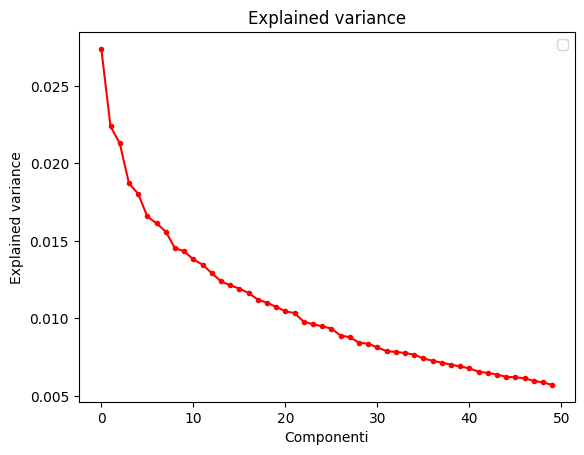

In [ ]:
exp_var = pca_preliminare.explained_variance_ratio_
print('Explained variance totale delle prime 50 componenti della PCA: {}'.format(sum(exp_var)))

for i in range(0,len(exp_var)):
  print('explained variance componente: ',i, ' = ', exp_var[i])

plt.plot(np.arange(0,len(exp_var)), exp_var, '.-', color='red')
plt.title('Explained variance')
plt.xlabel('Componenti')
plt.ylabel('Explained variance')
plt.legend()
plt.show()

Di seguito si riporta il plot delle prime due componenti dello spazio latente ricostruito con PCA. Si osserva sulla sinistra una forte sovrapposizione fra i 3 dataset. In particolare in tale area si osserva qualitativamente che la sovrapposizione low-normal è maggiore di quella high-normal come atteso. Sulla parte destra invece si accumulano principalmente dati high ed i low in maniera minore.I normali sono invece praticamente assenti in tale zona.

Text(0, 0.5, 'pca[1]')

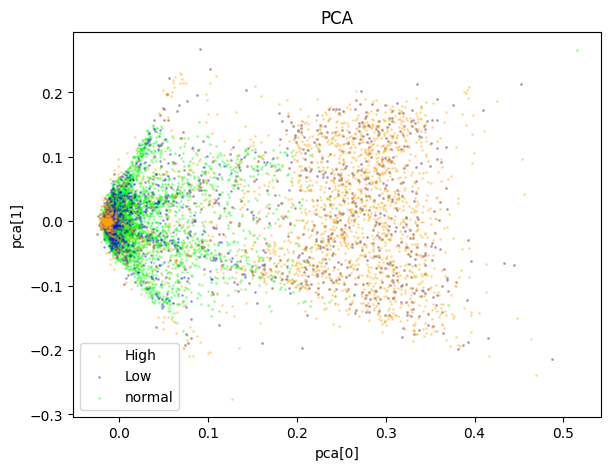

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.scatter(high_data_pca[:, 0], high_data_pca[:, 1],color="orange", label="High",s=1,alpha = 0.3,zorder =6)
plt.scatter(low_data_pca[:, 0], low_data_pca[:, 1],color="blue", label="Low",s=1,alpha = 0.3,zorder=5)
plt.scatter(normal_data_pca[:, 0], normal_data_pca[:, 1],color="lime", label="normal",s=1,alpha = 0.3)

plt.legend()
plt.title("PCA")
plt.xlabel("pca[0]")
plt.ylabel("pca[1]")

A partire da tali considerazioni è inoltre possibile realizzare un clustering preliminare su tale rappresentazione latente. Tale rappresentazione realizzata con PCA è eslusivamente data da una trasformazione lineare.

In [ ]:
from sklearn.mixture import GaussianMixture

#unisco i dati low e high
low_and_high = np.concatenate((low_data_pca,high_data_pca), axis = 0)

gmm_preliminare = GaussianMixture(n_components=2, max_iter=500, random_state=12345)
gmm_preliminare.fit(low_and_high)

cluster_labels = gmm_preliminare.predict(low_and_high)


/tmp/ipython-input-271-380170583.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'pca[1]')

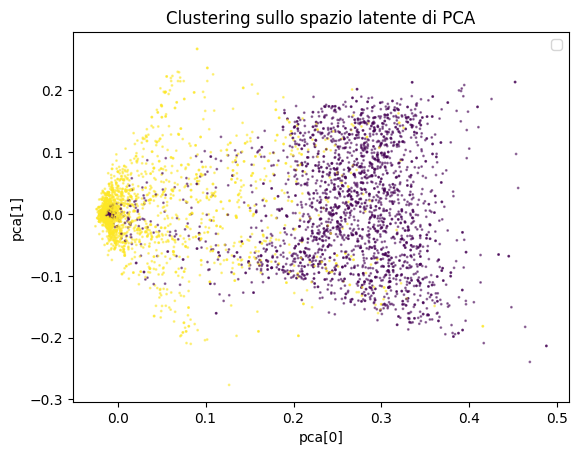

In [ ]:
plt.scatter(low_and_high[:, 0], low_and_high[:, 1], c = cluster_labels,s=1,alpha = 0.5)
plt.legend()
plt.title("Clustering sullo spazio latente di PCA")
plt.xlabel("pca[0]")
plt.ylabel("pca[1]")

Si osserva che il clustering separa come atteso da considerazioni qualitative.

# Autoencoder

**Architettura:** Autoencoder convoluzionale con encoder costituito da 3 layer convoluzionali 2D con kernel_size=4 e stride=2, che comprimono progressivamente la rappresentazione spaziale dell'immagine di input. Il decoder è simmetricamente costruito tramite 3 layer ConvTranspose2d che ricostruiscono l'immagine dallo spazio latente. Lo spazio latente z è rappresentato da un layer completamente connesso (Linear) di dimensione definibile.

Si usano attivazioni ReLU dopo ogni layer convoluzionale e trasposto, mentre l’output finale è attivato tramite una funzione sigmoide, così da ottenere un'immagine ricostruita con valori di pixel normalizzati in [0, 1]. Questo consente di allenare il modello utilizzando la Binary Cross Entropy Loss (BCELoss) come funzione di perdita.

In [ ]:


class Encoder(nn.Module):
    def __init__(self, hidden_channels=64, latent_dim=2):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=hidden_channels*3,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            in_channels=hidden_channels*3,
            out_channels=hidden_channels*2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            in_channels=hidden_channels*2,
            out_channels=hidden_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.fc_z = nn.Linear(in_features=hidden_channels*12*12,out_features=latent_dim)

        self.activation = nn.ReLU()

    def forward(self, x):

        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))
        x = self.activation(self.conv3(x))

        x = x.view(x.shape[0], -1) #flatten

        z = self.fc_z(x)

        return z





In [ ]:
class Decoder(nn.Module):
    def __init__(self, hidden_channels=64, latent_dim=2):
        super().__init__()
        self.hidden_channels = hidden_channels

        self.fc = nn.Linear(in_features=latent_dim,out_features=hidden_channels*12*12)

        self.conv3 = nn.ConvTranspose2d(
            in_channels=hidden_channels,
            out_channels=hidden_channels*2,
            kernel_size=4,
            stride=2,
            padding=1,
            output_padding=1
        )
        self.conv2 = nn.ConvTranspose2d(
            in_channels=hidden_channels*2,
            out_channels=hidden_channels*3,
            kernel_size=4,
            stride=2,
            padding=1
        )
        self.conv1 = nn.ConvTranspose2d(
            in_channels=hidden_channels*3,
            out_channels=1,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.activation = nn.ReLU()


    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), self.hidden_channels, 12, 12)
        x = self.activation(self.conv3(x))
        x = self.activation(self.conv2(x))
        out = torch.sigmoid(self.conv1(x))
        return out

Bisogna fare attenzione che le dimensioni siano tutte coerenti. In particolare conoscere la lunghezza dell' array flattened.
Per fare ciò in fase di scrittura della rete si istanzia l'encoder e se ne cancella momentaneamente il nn.linear per vedere la dimensionalità in uscita dall' ultimo layer convoluzionale usando torch.summary.


In [ ]:


hidden_channels = 16
latent_dim = 20 #dimensione dello spazio latente z

encoder = Encoder(hidden_channels=hidden_channels, latent_dim=latent_dim)

print(encoder)

from torchsummary import summary
if torch.cuda.is_available():
  summary(encoder.cuda(), input_size=(1,100,100))
else:
  summary(encoder, input_size=(1,100,100))



Encoder(
  (conv1): Conv2d(1, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(48, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (fc_z): Linear(in_features=2304, out_features=20, bias=True)
  (activation): ReLU()
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 48, 50, 50]             816
              ReLU-2           [-1, 48, 50, 50]               0
            Conv2d-3           [-1, 32, 25, 25]          24,608
              ReLU-4           [-1, 32, 25, 25]               0
            Conv2d-5           [-1, 16, 12, 12]           8,208
              ReLU-6           [-1, 16, 12, 12]               0
            Linear-7                   [-1, 20]          46,100
Total params: 79,732
Trainable params: 79,732
Non-trainable params: 0
--------------------------

In [ ]:
# Full AE Model
class AE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        z = self.encoder(x)
        x_reco = self.decoder(z)
        return x_reco

In [ ]:
# istanzio il decoder verificando di avere in uscita
#immagini di dimensione 100x100

decoder = Decoder(hidden_channels=hidden_channels, latent_dim=latent_dim)

print(decoder)

from torchsummary import summary
if torch.cuda.is_available():
  summary(decoder.cuda(), input_size=(1,latent_dim))
else:
  summary(decoder, input_size=(1,latent_dim))


Decoder(
  (fc): Linear(in_features=20, out_features=2304, bias=True)
  (conv3): ConvTranspose2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (conv2): ConvTranspose2d(32, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv1): ConvTranspose2d(48, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (activation): ReLU()
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 1, 2304]          48,384
   ConvTranspose2d-2           [-1, 32, 25, 25]           8,224
              ReLU-3           [-1, 32, 25, 25]               0
   ConvTranspose2d-4           [-1, 48, 50, 50]          24,624
              ReLU-5           [-1, 48, 50, 50]               0
   ConvTranspose2d-6          [-1, 1, 100, 100]             769
Total params: 82,001
Trainable params: 82,001
Non-trainable params: 0
------------------------------------------

In [ ]:
#Istanzio il modello completo
model_ae = AE(encoder, decoder)

print(model_ae)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model_ae.cuda(), input_size=(1,100,100))
else:
  summary(model_ae, input_size=(1,100,100))

AE(
  (encoder): Encoder(
    (conv1): Conv2d(1, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(48, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv3): Conv2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (fc_z): Linear(in_features=2304, out_features=20, bias=True)
    (activation): ReLU()
  )
  (decoder): Decoder(
    (fc): Linear(in_features=20, out_features=2304, bias=True)
    (conv3): ConvTranspose2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (conv2): ConvTranspose2d(32, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv1): ConvTranspose2d(48, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (activation): ReLU()
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 48, 50, 50]             816
              ReLU-2           [-1, 48, 50, 50]  

#Modello usato

Sperimentando con la dimensione della rete, la configurazione hidden_channels = 16, latent_dim = 20 ha fornito risultati consistenti in termine di purezza del clustering e divisione visiva dei clusters.

In [ ]:
#Instanziamo il modello

hidden_channels = 16 #numero filtri convoluzionali primo layer conv.
latent_dim = 20 #dimensione dello spazio latente z

encoder = Encoder(hidden_channels=hidden_channels, latent_dim=latent_dim)
decoder = Decoder(hidden_channels=hidden_channels, latent_dim=latent_dim)
model_ae = AE(encoder, decoder)

print(model_ae)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model_ae.cuda(), input_size=(1,100,100))
else:
  summary(model_ae, input_size=(1,100,100))

AE(
  (encoder): Encoder(
    (conv1): Conv2d(1, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(48, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv3): Conv2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (fc_z): Linear(in_features=2304, out_features=20, bias=True)
    (activation): ReLU()
  )
  (decoder): Decoder(
    (fc): Linear(in_features=20, out_features=2304, bias=True)
    (conv3): ConvTranspose2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (conv2): ConvTranspose2d(32, 48, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (conv1): ConvTranspose2d(48, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (activation): ReLU()
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 48, 50, 50]             816
              ReLU-2           [-1, 48, 50, 50]  

In [ ]:
# testiamo il modello su un batch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ae=model_ae.to(device)

x,_ =  next(iter(normal_train_dl)) #è un AE non ci servono le label
x=x.to(device)

z = encoder(x)
xtilde = model_ae(x)

print(z.shape)  #batch_size x latent_space
print(xtilde.shape) #batch_sizexn_channelsx100x100

torch.Size([64, 20])
torch.Size([64, 1, 100, 100])


Si è adoperata una  BCE poichè i dati sono normalizzati ad 1 mediante una sigmoide.

In [ ]:
# optim
from torch import optim
LR = 1.e-5
opt = torch.optim.Adam(params=model_ae.parameters(), lr=LR, weight_decay=1e-5)

def loss_func(recon_x, x):
    recon_loss = F.binary_cross_entropy(recon_x.view(-1, 100*100), x.view(-1, 100*100))
    return recon_loss

In [ ]:
import time

epochs = 10
hist_loss = []
hist_test_loss = []

for epoch in range(epochs):
    t0 = time.time()

    # training step
    model_ae.train()
    train_loss = 0
    counter = 0

    for xb, _ in normal_train_dl:
        counter += 1
        xb = xb.to(device)

        xhat = model_ae(xb)
        loss = loss_func(xhat, xb)

        train_loss += loss.item()

        # backpropagation
        opt.zero_grad()
        loss.backward()
        opt.step()

    train_loss /= counter
    hist_loss.append(train_loss)
    # evaluation step
    model_ae.eval()
    test_loss = 0
    test_counter = 0

    with torch.no_grad():
        for xb_test, _ in normal_test_dl:
            test_counter += 1
            xb_test = xb_test.to(device)

            xhat_test = model_ae(xb_test)
            loss_test = loss_func(xhat_test, xb_test)

            test_loss += loss_test.item()

    test_loss /= test_counter
    hist_test_loss.append(test_loss)  # <-- salviamo la test loss
    elapsed_time = time.time() - t0
    print("epoch: %d, time(s): %.4f, train loss: %.6f, test loss: %.6f"
          % (epoch + 1, elapsed_time, train_loss, test_loss))



epoch: 1, time(s): 4.9102, train loss: 0.747686, test loss: 0.744568
epoch: 2, time(s): 5.1619, train loss: 0.700989, test loss: 0.570726
epoch: 3, time(s): 4.8937, train loss: 0.290704, test loss: 0.092175
epoch: 4, time(s): 4.9250, train loss: 0.050153, test loss: 0.029107
epoch: 5, time(s): 5.3210, train loss: 0.021902, test loss: 0.016647
epoch: 6, time(s): 4.8548, train loss: 0.013448, test loss: 0.010680
epoch: 7, time(s): 5.4020, train loss: 0.008679, test loss: 0.006945
epoch: 8, time(s): 4.8255, train loss: 0.005539, test loss: 0.004329
epoch: 9, time(s): 4.7741, train loss: 0.003534, test loss: 0.002878
epoch: 10, time(s): 5.1584, train loss: 0.002443, test loss: 0.002078


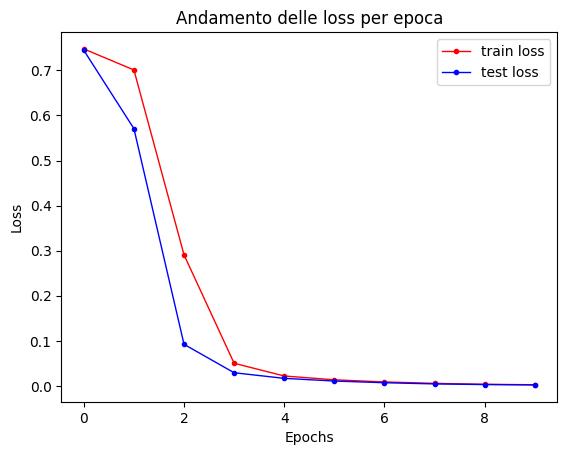

In [ ]:
# training loss plot

plt.plot(np.arange(0,len(hist_loss)), hist_loss, '.-', color='red', linewidth = 1, label='train loss')
plt.plot(np.arange(0,len(hist_test_loss)), hist_test_loss, '.-', color='blue', linewidth = 1, label='test loss')
plt.title("Andamento delle loss per epoca")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#Anomaly Detection

La funzione 'loss_and_latent' di seguito prende in input un certo dataloader e la dimensione dello spazio latente di cui sopra. Essa permette di generare lo spazio latente e calcolare la loss per ogni esempio nel dataloader. Si è impostata batch_size = 1 per il test.
Per svolgere questi compiti il modello si imposta in modalità 'eval()'. Di particolare importanza è che tale funzione restituisce 'parallelamente' lo spazio latente, la loss e l' esempio specifico (immagine 100x100) in modo da mantenere l'ordine relativo e l'accoppiamento opportuno.

In [ ]:
def loss_and_latent(dataloader,dim_latente):
  model_ae.eval()
  model_ae.to(device)
  z = np.empty(shape=(len(dataloader),dim_latente)) #funziona perchè ho batchsize = 1
  loss_hist = []
  img_originale = []

  with torch.no_grad():

    for idx, (xb,_) in enumerate(dataloader): #errore
      xb=xb.to(device)
      img_originale.append((xb.cpu())[0].view(100,100).detach().numpy())

      zl = model_ae.encoder(xb)
      pred_tp = model_ae.decoder(zl)
      res = loss_func(pred_tp,xb)
      loss_hist.append(res.item())
      z[idx,:] = zl[0,:].cpu().numpy() #vettore z
  return z,np.array(loss_hist),np.array(img_originale)

In [ ]:
latent_dim = 20


train_latent,train_loss,img_train = loss_and_latent(latent_train_dl,dim_latente = latent_dim)
normal_latent,test_loss,img_test = loss_and_latent(normal_test_dl,dim_latente = latent_dim)
low_latent,low_loss,img_low = loss_and_latent(mixture_dl_l,dim_latente = latent_dim)
high_latent,high_loss,img_high = loss_and_latent(mixture_dl_h,dim_latente = latent_dim)

Di seguito si mostra l'istogramma delle loss sul dataset di train e di test con batch_size = 1. Se il modello soffrisse di overfitting osserveremmo una loss sul Trainset patologicamente inferiore. Inoltre è importante valutare lo spazio latente del trainset in modo da poter normalizzare tale spazio evitando data leakage.

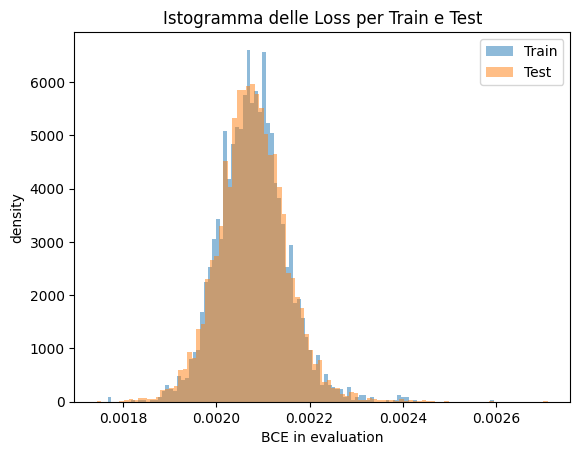

In [ ]:
n_bins = 100
_ = plt.hist(test_loss, alpha=0.5, density=True,  label='Train',bins=n_bins)
_ = plt.hist(train_loss, alpha=0.5, density=True, label='Test',bins=n_bins)
plt.title("Istogramma delle Loss per Train e Test")
plt.xlabel("BCE in evaluation")
plt.ylabel("density")
plt.legend()

Per garantire come richiesto FPR < 10% si fissa una soglia in corrispondenza del 90° percentile della loss degli esempi normali e si  determinano le labels relative agli esempi. Gli esempi la cui loss di ricostruzione sia superiore a tale valore di soglia verranno considerati anomali.



Si riporta di seguito i risultati ottenuti per una run specifica.
Il grafico di seguito evidenzia la presenza attesa di anomalie nei dataset low e high. In particolare il dataset nomal_test presenta un solo picco poichè non contiene jet anomali. D'altra parte i dataset low e high presentano un doppio picco corrispondente.






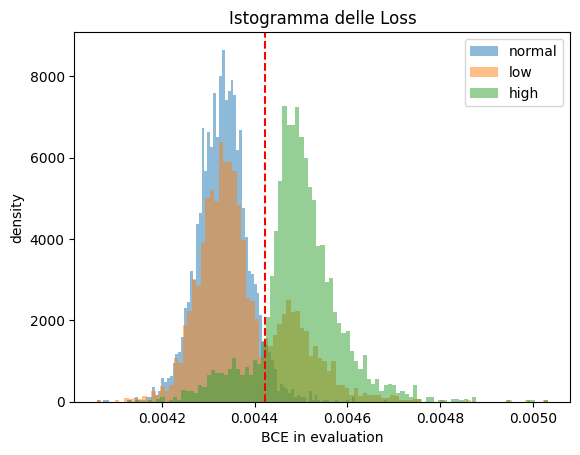


Per cui si ottiene:


*   Frazione stimata di an-omalie in low: 31.40%
*   Frazione stimata di anomalie in high: 90.03%

*   Soglia usata (garantisce FPR ≤ 10%): 0.0044





Di seguito si ha invece il plot relativo a questa run specifica.

Frazione stimata di an-omalie in low: 32.97%
Frazione stimata di anomalie in high: 91.67%
Soglia usata (garantisce FPR ≤ 10%): 0.00216471825260669


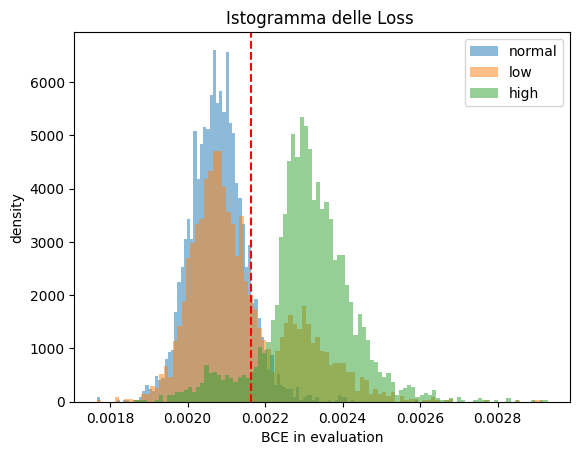

In [ ]:
"""
Nel primo dataset (_high) la frazione incognita di eventi anomali è  ≥55% .
Nel secondo dataset (_low) la frazione incognita di eventi anomali incognita è  ≤45% .
"""

plt.title("Istogramma delle Loss ")
plt.xlabel("BCE in evaluation")
plt.ylabel("density")
_ = plt.hist(test_loss, alpha=0.5, density=True,  label='normal',bins=n_bins)
_ = plt.hist(low_loss, alpha=0.5, density=True, label='low',bins=n_bins)
_ = plt.hist(high_loss, alpha=0.5, density=True, label='high',bins=n_bins)
plt.legend()

threshold = np.percentile(test_loss, 90)

# Calcolo su test set 1
label_low = (low_loss > threshold)
frac_l = label_low.mean()

# Calcolo su test set 2
label_high = high_loss > threshold
frac_h = label_high.mean()


print(f"Frazione stimata di an-omalie in low: {frac_l:.2%}")
print(f"Frazione stimata di anomalie in high: {frac_h:.2%}")
print(f"Soglia usata (garantisce FPR ≤ 10%): {threshold}")
plt.axvline(threshold, color='r', linestyle='--')

plt.show()


#Spazio Latente

Di seguito si rende ciascuna variabile dello spazio latente a media nulla e varianza unitaria. Ciò è utile nelle operazioni di clustering affinchè le variabili acquisiscano indistintamente il medesimo 'peso'.
Di particolare importanza è effettuare tale normalizzazione sullo spazio latente del train set per evitare data leakage.


In [ ]:
#standardizzo il latente
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(train_latent)          # solo eventi “puliti”
Z_norm_sc  = sc.transform(normal_latent)
Z_low_sc   = sc.transform(low_latent)
Z_high_sc  = sc.transform(high_latent)

La funzione di seguito plotta le prime due componenti dello spazio latente con le relative label di classe trovate.


In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch   # per creare i rettangoli in legenda

def latent_plotter(latent_space, labels, titolo="Titolo",legenda = True):
    # colori fissi per 0 e 1
    colors = ["yellow", "red"]       # 0 → yellow, 1 → red
    my_cmap = ListedColormap(colors, name="my_cmap")


    # scatter unico: i colori sono presi dal cmap in base a labels (0 o 1)
    plt.scatter(latent_space[:, 0],latent_space[:, 1],c=labels,cmap=my_cmap,s=1,alpha=0.3)

    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title(titolo)
    if legenda == True:
      # legenda personalizzata
      legend_handles = [Patch(color=colors[0], label="Normale (0)"), Patch(color=colors[1], label="Anomalo (1)")]
      plt.legend(handles=legend_handles, title="Classe", loc="upper right")

    plt.tight_layout()
    #plt.show()


A partire dalle labels trovate dall' anomaly detection realizzata con l'AE si plottano di seguito le prime due componenti per i 3 dataset a disposizione.

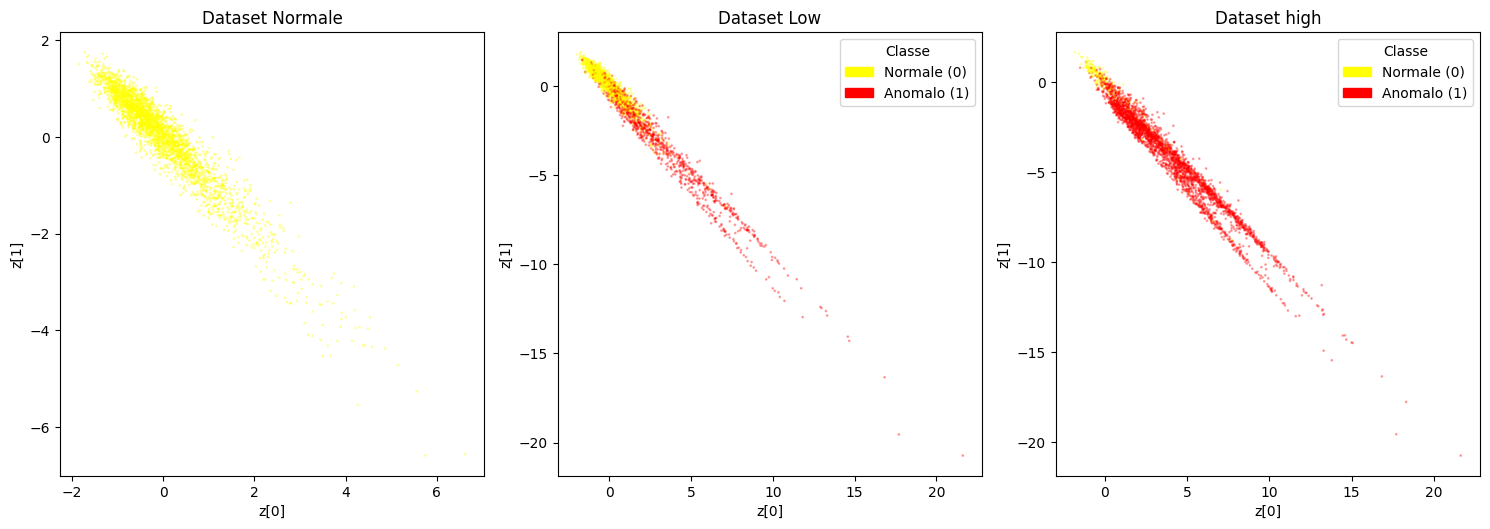

In [ ]:
plt.figure(figsize = (15,15))
plt.subplot(3,3,1)
latent_plotter(Z_norm_sc,np.zeros(len(Z_norm_sc)),titolo="Dataset Normale",legenda=False)
plt.subplot(3,3,2)
latent_plotter(Z_low_sc,label_low,titolo="Dataset Low")
plt.subplot(3,3,3)
latent_plotter(Z_high_sc,label_high,titolo="Dataset high")


#Ulteriori visualizzazioni

In [ ]:
import pandas as pd

A partire dalla labels trovate nei punti precedenti è utile unire insieme tutti gli esempi classificati come anomali e visualizzarne le differenze globali rispetto agli esempi normali.

Di seguito si ottiene un dataset di soli eventi anomali. Poichè è noto che all'interno del normal dataset vi sono soltanto eventi normali queste due categorie di possono visualizzare ora separatemente.

In [ ]:
normalized_latent_anomal_from_low = Z_low_sc[label_low]
normalized_latent_anomal_from_high = Z_high_sc[label_high]

anomal_img_from_low = img_low[label_low]
anomal_img_from_high = img_high[label_high]

anomal_loss_from_low = low_loss[label_low]
anomal_loss_from_high = high_loss[label_high]

print(normalized_latent_anomal_from_low.shape[0]/3000)
print(normalized_latent_anomal_from_high.shape[0]/3000)
#tornano con le dimensioni di cui sopra le percentuali

0.32966666666666666
0.9166666666666666


In [ ]:
latent_img_anomal = np.concatenate([anomal_img_from_low,anomal_img_from_high])
latent_loss_anomal = np.concatenate([anomal_loss_from_low,anomal_loss_from_high])
latent_all_anomal = np.concatenate([normalized_latent_anomal_from_low,normalized_latent_anomal_from_high])


Avendo separato allora gli eventi normali ed anomali plottiamo gli istogrammi delle loss per queste due classi separatamente.


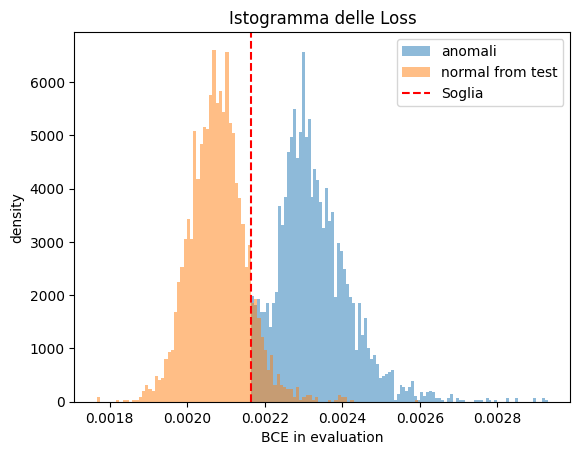

In [ ]:

plt.title("Istogramma delle Loss")
plt.xlabel("BCE in evaluation")
plt.ylabel("density")
_ = plt.hist(latent_loss_anomal, alpha=0.5, density=True,  label='anomali',bins=n_bins)
_ = plt.hist(test_loss, alpha=0.5, density=True,  label='normal from test',bins=n_bins)



plt.axvline(threshold, color='r', linestyle='--',label="Soglia")
plt.legend()

plt.show()


Di seguito si realizzano i grafici relativi alle immagini orginali per esempi normali ed etichettati come anomali

**Dati Normali**

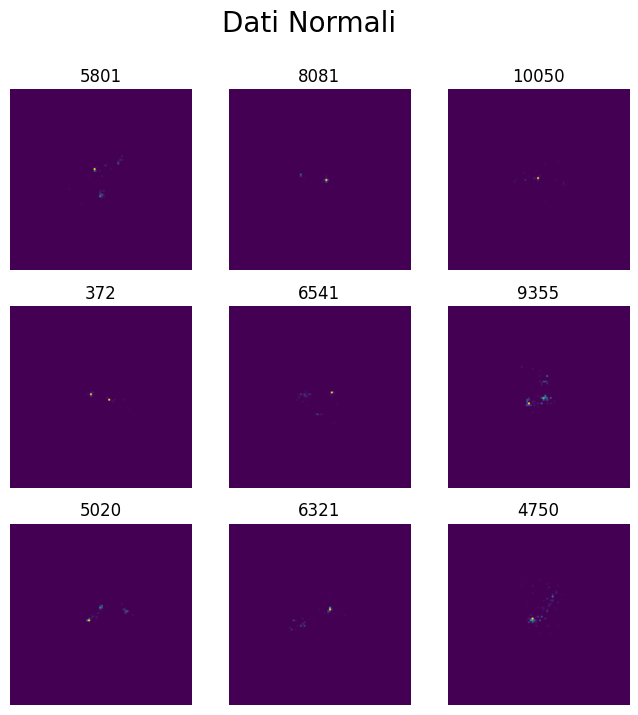

<Figure size 640x480 with 0 Axes>

In [ ]:
##plot dei dati normali

figure = plt.figure(figsize=(8, 8))
cols, rows = 3,3
images = normal_data
plt.suptitle("Dati Normali", fontsize=20)  # Titolo principale ben visibile
for i in range(1, cols * rows + 1):
    sample_idx = np.random.randint(len(images))
    img = images[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(sample_idx)
    plt.axis("off")
    plt.imshow(img.reshape((100,100)))
plt.show()
plt.tight_layout()





**Dati Anomali**

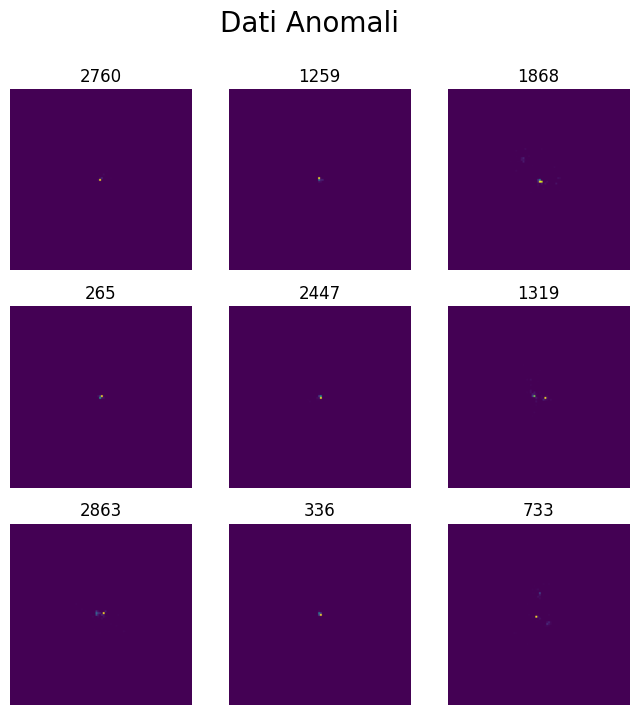

In [ ]:

# Plot dei dati anomali

figure = plt.figure(figsize=(8, 8))
cols, rows = 3,3
images = latent_img_anomal
plt.suptitle("Dati Anomali", fontsize=20)  # Titolo principale ben visibile

for i in range(1, cols * rows + 1):
    sample_idx = np.random.randint(len(images))
    img = images[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(sample_idx)
    plt.axis("off")
    plt.imshow(img.reshape((100,100)))
plt.show()

**Osservazione**



Le visualizzazioni di cui sopra sono coerenti con l'interpretazione fisica dei jet normali ed anomali.
I primi presentano differenti hits relative a particelle non completamente collimate mentre i secondi (a meno di errori di labeling) presentano una unica hit centrale.

#Clustering

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
Z_low_and_high = np.concatenate([Z_low_sc,Z_high_sc])
gmm_train = GaussianMixture(n_components=2,covariance_type='full',).fit(Z_low_and_high)
cl_low   = gmm_train.predict(Z_low_sc)
cl_high   = gmm_train.predict(Z_high_sc)



Si considera  la seguente $\text{Purezza} = \frac{1}{N} \sum_{k=1}^{K} \max_{j} |C_k \cap L_j|$.
Ove con $L_j$ si intendono le label assegnate al cluster $C_k$ . In particolare si sceglie la configurazione che massimizzi la sovrapposizione fra tali labels.




Si specifica che di principio il caso in esame non è supervisionato e che dunque le denominazioni certe dei clusters non sono note a priori. Tuttavia si può valutare la 'purezza relativa' fra labels trovate mediante clustering gmm e le labels trovate come soglia dell' anomaly detection realizzata con l'AE.

Di principio la corrispondenza delle labels ottenute da un algoritmo di clustering è casuale. La funzione di seguito ha lo scopo di raccordare la notazione di tali labels in modo tale di massimizzare la relativa purezza cone le labels ottenute dall' autoencoder.   

In [ ]:
def purity_maxer(cluster_label, true_labels):
    new_labels = cluster_label

    pur_sum_base = np.sum(cluster_label == true_labels)/ len(true_labels)
    pur_sum_swap = np.sum((1-cluster_label) == true_labels)/ len(true_labels)


    purezza = max(pur_sum_base,pur_sum_swap)
    if pur_sum_swap > pur_sum_base: #swappo
      new_labels = 1 - cluster_label


    return new_labels,purezza






In [ ]:
cluster_label_low,low_purity  = purity_maxer(cl_low,label_low)
cluster_label_high,high_purity  = purity_maxer(cl_high,label_high)

print(f"Purezza labeling dataset low: {low_purity*100 :.4}%")
print(f"Purezza labeling dataset  high: {high_purity*100 :.4}%")

Purezza labeling dataset low: 82.67%
Purezza labeling dataset  high: 70.37%


Dal plot di seguito inoltre si osserva qualitativamente l'accordo fra il labeling ottenuto mediante strategie diverse.

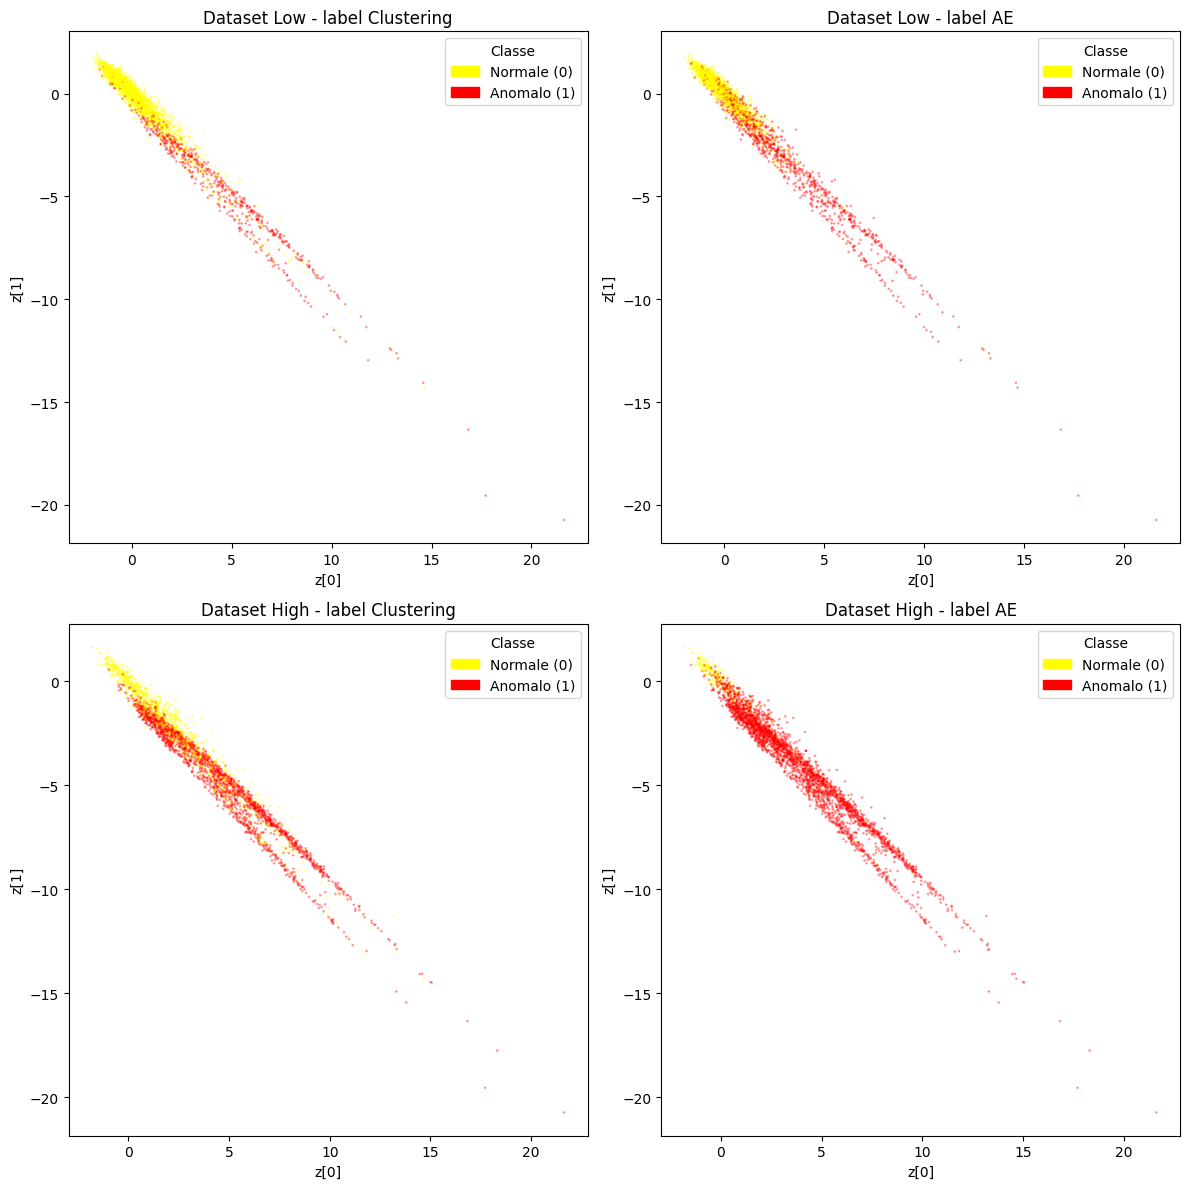

In [ ]:
plt.figure(figsize=(12,12))
plt.subplot(2,2,1)
latent_plotter(Z_low_sc,cluster_label_low,titolo="Dataset Low - label Clustering")
plt.subplot(2,2,2)
latent_plotter(Z_low_sc,label_low,titolo="Dataset Low - label AE")


plt.subplot(2,2,3)
latent_plotter(Z_high_sc,cluster_label_high,titolo="Dataset High - label Clustering")
plt.subplot(2,2,4)
latent_plotter(Z_high_sc,label_high,titolo="Dataset High - label AE")


#Appendice VAE:


Il VAE (Variational Autoencoder) apprende una distribuzione continua di probabilità nello spazio latente. Per questo motivo, si è ipotizzato che il VAE fosse più affidabile nella stima della percentuale di anomalie nei dataset 'low' e 'high'. Inoltre, è stato osservato empiricamente che il VAE fornisce stime più stabili rispetto all'Autoencoder tradizionale.


 Tuttavia si precisa che un VAE non può funzionare come labeler degli esempi dati in quanto esso non non produce una singola rappresentazione latente deterministica per ciascun input, ma esegue un campionamento a partire dalla distribuzione appresa.

In [ ]:
# Convolutional Encoder Model

class VAE_Encoder(nn.Module):
    def __init__(self, hidden_channels=64, latent_dim=2):
        super().__init__()


        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=hidden_channels*3,
                               kernel_size=(3,3),
                               stride=(2,2))

        self.conv2 = nn.Conv2d(in_channels=hidden_channels*3,
                               out_channels=hidden_channels*2,
                               kernel_size=(3,3),
                               stride=(2,2))

        self.conv3 = nn.Conv2d(in_channels=hidden_channels*2,
                               out_channels=hidden_channels,
                               kernel_size=(3,3),
                               stride=(1,1))

        self.fc_logvar = nn.Linear(in_features=hidden_channels*22*22,out_features=latent_dim)


        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.conv1(x))
        x = self.activation(self.conv2(x))
        x = self.activation(self.conv3(x))

        x = x.reshape(x.shape[0], -1) #flatten
        x_mu = self.fc_logvar(x)
        x_logvar = self.fc_logvar(x)
        return x_mu, x_logvar



# Convolutional Decoder Model

class VAE_Decoder(nn.Module):
    def __init__(self, hidden_channels=64, latent_dim=2):
        super().__init__()
        self.hidden_channels = hidden_channels

        self.fc = nn.Linear(in_features=latent_dim,out_features=hidden_channels*22*22)

        self.conv3 = nn.ConvTranspose2d(in_channels=hidden_channels,
                                        out_channels=hidden_channels*2,
                                        kernel_size=(3,3),
                                        stride=(1,1))
        self.conv2 = nn.ConvTranspose2d(in_channels=hidden_channels*2,
                                        out_channels=hidden_channels*3,
                                        kernel_size=(3,3),
                                        stride=(2,2))
        self.conv1 = nn.ConvTranspose2d(in_channels=hidden_channels*3,
                                        out_channels=1,
                                        kernel_size=(3,3),
                                        stride=(2,2),output_padding=(1,1))

        self.activation = nn.ReLU()


    def forward(self, x):
        x = self.fc(x)
        x = x.view(x.size(0), self.hidden_channels, 22, 22)
        x = self.activation(self.conv3(x))
        x = self.activation(self.conv2(x))
        out = torch.sigmoid(self.conv1(x))
        return out


In [ ]:

class VAE(nn.Module):
  def __init__(self, encoder,decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, x):
    x_mu, x_logvar = self.encoder(x)
    z = self.rep_trick(x_mu, x_logvar)
    out = self.decoder(z)
    return out, x_mu, x_logvar

  def rep_trick(self, x_mu, x_logvar):
    if self.training:
      sigma = (0.5*x_logvar ).exp() #sigma ben posta sempre positiva
      z = x_mu + sigma*torch.randn_like(sigma)
      return z
    else:
      return x_mu


In [ ]:
#instazio il modello
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_channels = 16
latent_dim = 5

VAE_encoder = VAE_Encoder(hidden_channels=hidden_channels, latent_dim=latent_dim)
VAE_decoder = VAE_Decoder(hidden_channels=hidden_channels, latent_dim=latent_dim)

model_vae = VAE(VAE_encoder, VAE_decoder)

print(model_vae)

from torchsummary import summary
if torch.cuda.is_available():
  summary(model_vae.cuda(), input_size=(1,100,100))
else:
  summary(model_vae, input_size=(1,100,100))

VAE(
  (encoder): VAE_Encoder(
    (conv1): Conv2d(1, 48, kernel_size=(3, 3), stride=(2, 2))
    (conv2): Conv2d(48, 32, kernel_size=(3, 3), stride=(2, 2))
    (conv3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
    (fc_logvar): Linear(in_features=7744, out_features=5, bias=True)
    (activation): ReLU()
  )
  (decoder): VAE_Decoder(
    (fc): Linear(in_features=5, out_features=7744, bias=True)
    (conv3): ConvTranspose2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (conv2): ConvTranspose2d(32, 48, kernel_size=(3, 3), stride=(2, 2))
    (conv1): ConvTranspose2d(48, 1, kernel_size=(3, 3), stride=(2, 2), output_padding=(1, 1))
    (activation): ReLU()
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 48, 49, 49]             480
              ReLU-2           [-1, 48, 49, 49]               0
            Conv2d-3           [-1, 32, 24, 24]          13,856
     

La loss di una VAE è composta da due termini, un contribuito di ricostruzione (BCE) ed uno di regolarizzazione (KL). Il primo di essi ottimizza la ricostruzione dell' input, il secondo ottimizza l'accordo della pdf trovata rispetto alla prior (gaussiana). Il peso della regolarizzazione si parametrizza in genere con un pararametro $\beta$ posto in questo caso pari ad 1.

In [ ]:
def vae_loss(recon_x, x, x_mu, log_var, beta):
    batch_size = x.size(0)
    recon_loss = F.binary_cross_entropy(
        recon_x.view(batch_size, -1),
        x.view(batch_size, -1),
        reduction='sum'
    ) / batch_size  # normalizzo per la batch per confrontare train loss e test loss
    kl_divergence = -0.5 * torch.sum(1 + log_var - x_mu.pow(2) - log_var.exp()) / batch_size
    return recon_loss + beta * kl_divergence, recon_loss, kl_divergence


from torch import optim
LR = 1.e-5
opt = torch.optim.Adam(params=model_vae.parameters(), lr=LR, weight_decay=1e-5)

epoch: 1, time(s): 5.16, train loss: 8363.368970, test loss: 8312.083638
epoch: 2, time(s): 5.65, train loss: 7218.190799, test loss: 6875.827930
epoch: 3, time(s): 5.18, train loss: 4021.815880, test loss: 6065.212866
epoch: 4, time(s): 5.73, train loss: 3029.777089, test loss: 5335.925498
epoch: 5, time(s): 5.46, train loss: 2529.828748, test loss: 4749.121240
epoch: 6, time(s): 5.65, train loss: 2196.384147, test loss: 4275.455806
epoch: 7, time(s): 5.14, train loss: 1952.535679, test loss: 3873.558431
epoch: 8, time(s): 5.16, train loss: 1763.330425, test loss: 3521.369925
epoch: 9, time(s): 5.37, train loss: 1593.046368, test loss: 3217.709224
epoch: 10, time(s): 5.14, train loss: 1468.073619, test loss: 2947.359973
epoch: 11, time(s): 5.78, train loss: 1366.419153, test loss: 2707.697821
epoch: 12, time(s): 5.22, train loss: 1259.652465, test loss: 2492.442173
epoch: 13, time(s): 6.08, train loss: 1180.185212, test loss: 2300.769368
epoch: 14, time(s): 5.37, train loss: 1105.5673

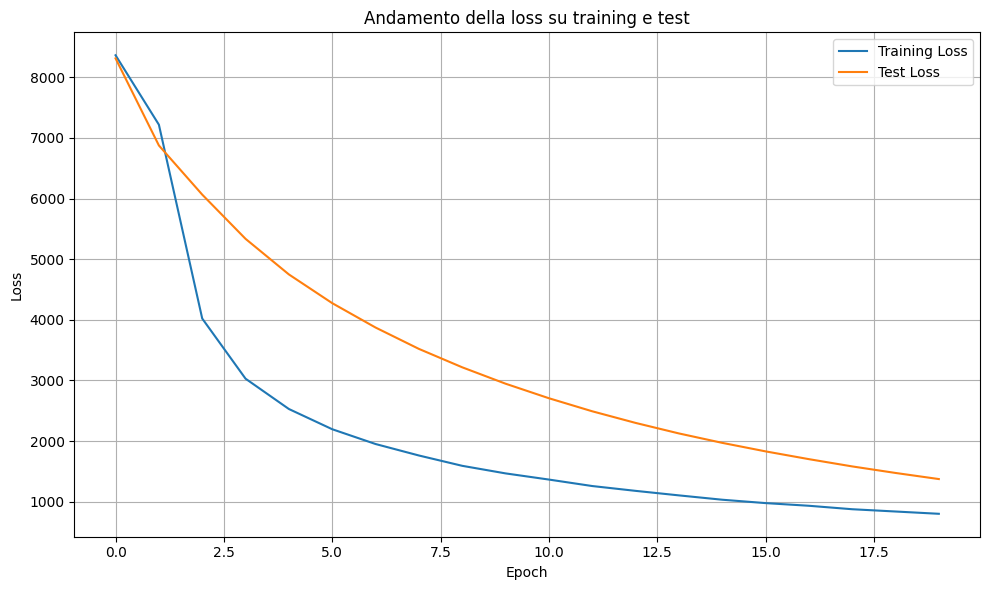

In [ ]:


import time
import matplotlib.pyplot as plt
model_vae = model_vae.to(device)
epochs = 20
beta = 1.0  #si può modificare questo parametro per aumentare o diminuire il peso della KL


hist_loss = []         # training loss
hist_test_loss = []    # test loss


for epoch in range(epochs):
    t0 = time.time()

    # Training
    model_vae.train()
    train_loss = 0
    counter = 0

    for xb, _ in normal_train_dl:
        counter += 1
        xb = xb.to(device)

        recon_x, x_mu, log_var = model_vae(xb)

        loss, recon_loss, kl_div = vae_loss(recon_x, xb, x_mu, log_var, beta)

        train_loss += loss.item()

        # Backpropagation
        opt.zero_grad()
        loss.backward()
        opt.step()

    train_loss /= counter
    hist_loss.append(train_loss)

    # Test loss
    model_vae.eval()
    test_loss = 0
    test_counter = 0

    with torch.no_grad():
        for xb, _ in normal_test_dl:
            test_counter += 1
            xb = xb.to(device)

            recon_x, x_mu, log_var = model_vae(xb)

            loss, recon_loss, kl_div = vae_loss(recon_x, xb, x_mu, log_var, beta)
            test_loss += loss.item()

    test_loss /= test_counter
    hist_test_loss.append(test_loss)

    elapsed_time = time.time() - t0
    print(f"epoch: {epoch+1}, time(s): {elapsed_time:.2f}, train loss: {train_loss:.6f}, test loss: {test_loss:.6f}")

# Plot delle loss
plt.figure(figsize=(10, 6))
plt.plot(hist_loss, label='Training Loss')
plt.plot(hist_test_loss, label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Andamento della loss su training e test")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Calcolo Anomaly Score usando la ricostruzione loss del VAE
model_vae.eval()
model_vae.to(device)

VAE_test_loss = []
VAE_low_loss = []
VAE_high_loss = []
VAE_train_loss = []

beta = 1.0

with torch.no_grad():

    # Normali
    for xb, _ in normal_test_dl:
        xb = xb.to(device)
        recon_x, x_mu, log_var = model_vae(xb)
        total_loss, recon_loss, kl_div = vae_loss(recon_x, xb, x_mu, log_var, beta)
        VAE_test_loss.append(total_loss.item())

    # Low
    for xb, _ in mixture_dl_l:
        xb = xb.to(device)
        recon_x, x_mu, log_var = model_vae(xb)
        total_loss, recon_loss, kl_div = vae_loss(recon_x, xb, x_mu, log_var, beta)
        VAE_low_loss.append(total_loss.item())

    # High
    for xb, _ in mixture_dl_h:
        xb = xb.to(device)
        recon_x, x_mu, log_var = model_vae(xb)
        total_loss, recon_loss, kl_div = vae_loss(recon_x, xb, x_mu, log_var, beta)
        VAE_high_loss.append(total_loss.item())

# Allineo la lunghezza per confronto
len_scelta = np.min([len(VAE_test_loss), len(VAE_low_loss), len(VAE_high_loss)])


Frazione stimata di an-omalie in low: 32.13%
Frazione stimata di anomalie in high: 90.60%
Soglia usata (garantisce FPR ≤ 10%): 1374.98330078125


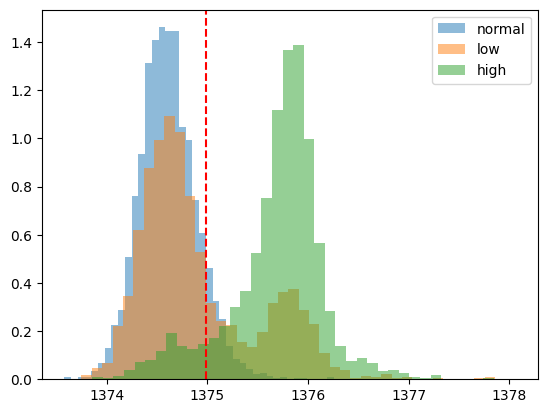

In [ ]:
#plot degli istogrammi delle loss di dati anomali e normali

_ = plt.hist(VAE_test_loss, alpha=0.5, density=True,  label='normal',bins=40)
_ = plt.hist(VAE_low_loss, alpha=0.5, density=True, label='low',bins=40)
_ = plt.hist(VAE_high_loss, alpha=0.5, density=True, label='high',bins=40)
plt.legend()

VAE_threshold = np.percentile(VAE_test_loss, 90)

# Calcolo su test set 1
VAE_pred_l = np.array([1 if s > VAE_threshold else 0 for s in VAE_low_loss])
VAE_frac_l = VAE_pred_l.mean()

# Calcolo su test set 2
VAE_pred_h = np.array([1 if s > VAE_threshold else 0 for s in VAE_high_loss])
VAE_frac_h = VAE_pred_h.mean()

print(f"Frazione stimata di an-omalie in low: {VAE_frac_l:.2%}")
print(f"Frazione stimata di anomalie in high: {VAE_frac_h:.2%}")
print(f"Soglia usata (garantisce FPR ≤ 10%): {VAE_threshold}")
plt.axvline(VAE_threshold, color='r', linestyle='--')

plt.show()



Si osserva che la separazione grafica fra le loss ottenuta dall' VAE risulta più netta rispetto a quanto ottenuto dal AE.